###Import Libraries

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np

###Device Configuration

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cpu


###Sample Dataset

In [3]:
pairs = [
    ("i am a student", "je suis un etudiant"),
    ("he is a teacher", "il est un professeur"),
    ("she is happy", "elle est heureuse"),
    ("i am learning", "j apprends"),
]

###Build Vocabulary

In [4]:
class Vocab:
    def __init__(self):
        self.word2index = {"<pad>":0, "<sos>":1, "<eos>":2}
        self.index2word = {0:"<pad>", 1:"<sos>", 2:"<eos>"}
        self.n_words = 3

    def add_sentence(self, sentence):
        for word in sentence.split():
            if word not in self.word2index:
                self.word2index[word] = self.n_words
                self.index2word[self.n_words] = word
                self.n_words += 1

input_vocab = Vocab()
output_vocab = Vocab()

for eng, fra in pairs:
    input_vocab.add_sentence(eng)
    output_vocab.add_sentence(fra)

###Convert Sentences to Tensors

In [5]:
def tensor_from_sentence(vocab, sentence):
    indexes = [vocab.word2index[word] for word in sentence.split()]
    indexes.append(vocab.word2index["<eos>"])
    return torch.tensor(indexes, dtype=torch.long, device=device).view(-1, 1)

###Encoder Model

In [6]:
class Encoder(nn.Module):
    def __init__(self, input_size, hidden_size):
        super().__init__()
        self.hidden_size = hidden_size
        self.embedding = nn.Embedding(input_size, hidden_size)
        self.gru = nn.GRU(hidden_size, hidden_size)

    def forward(self, x, hidden):
        embedded = self.embedding(x).view(1, 1, -1)
        output, hidden = self.gru(embedded, hidden)
        return output, hidden

    def init_hidden(self):
        return torch.zeros(1, 1, self.hidden_size, device=device)

###Attention Decoder

In [7]:
class AttnDecoder(nn.Module):
    def __init__(self, hidden_size, output_size, max_length=10):
        super().__init__()
        self.hidden_size = hidden_size
        self.output_size = output_size
        self.max_length = max_length

        self.embedding = nn.Embedding(output_size, hidden_size)
        self.attn = nn.Linear(hidden_size * 2, max_length)
        self.attn_combine = nn.Linear(hidden_size * 2, hidden_size)

        self.gru = nn.GRU(hidden_size, hidden_size)
        self.out = nn.Linear(hidden_size, output_size)

    def forward(self, input, hidden, encoder_outputs):
        embedded = self.embedding(input).view(1, 1, -1)

        attn_weights = torch.softmax(
            self.attn(torch.cat((embedded[0], hidden[0]), 1)), dim=1
        )

        attn_applied = torch.bmm(attn_weights.unsqueeze(0),
                                 encoder_outputs.unsqueeze(0))

        output = torch.cat((embedded[0], attn_applied[0]), 1)
        output = self.attn_combine(output).unsqueeze(0)

        output = torch.relu(output)
        output, hidden = self.gru(output, hidden)

        output = torch.log_softmax(self.out(output[0]), dim=1)
        return output, hidden, attn_weights

###Initialize Models

In [8]:
hidden_size = 256

encoder = Encoder(input_vocab.n_words, hidden_size).to(device)
decoder = AttnDecoder(hidden_size, output_vocab.n_words).to(device)

###Training Function

In [9]:
def train(input_tensor, target_tensor, encoder, decoder, optimizer, criterion, max_length=10):
    encoder_hidden = encoder.init_hidden()

    encoder_outputs = torch.zeros(max_length, encoder.hidden_size, device=device)

    loss = 0

    for ei in range(input_tensor.size(0)):
        encoder_output, encoder_hidden = encoder(input_tensor[ei], encoder_hidden)
        encoder_outputs[ei] = encoder_output[0, 0]

    decoder_input = torch.tensor([[1]], device=device)  # <sos>
    decoder_hidden = encoder_hidden

    for di in range(target_tensor.size(0)):
        decoder_output, decoder_hidden, attn_weights = decoder(
            decoder_input, decoder_hidden, encoder_outputs
        )
        loss += criterion(decoder_output, target_tensor[di])
        decoder_input = target_tensor[di]  # teacher forcing

    loss.backward()
    optimizer.step()

    return loss.item() / target_tensor.size(0)

###Train Loop

In [10]:
optimizer = optim.Adam(list(encoder.parameters()) + list(decoder.parameters()), lr=0.01)
criterion = nn.NLLLoss()

for epoch in range(300):
    total_loss = 0
    for eng, fra in pairs:
        input_tensor = tensor_from_sentence(input_vocab, eng)
        target_tensor = tensor_from_sentence(output_vocab, fra)

        optimizer.zero_grad()
        loss = train(input_tensor, target_tensor, encoder, decoder, optimizer, criterion)
        total_loss += loss

    if epoch % 50 == 0:
        print(f"Epoch {epoch}, Loss: {total_loss:.4f}")

Epoch 0, Loss: 11.7282
Epoch 50, Loss: 0.0028
Epoch 100, Loss: 0.0012
Epoch 150, Loss: 0.0007
Epoch 200, Loss: 0.0005
Epoch 250, Loss: 0.0003


###Evaluate + Get Attention

In [11]:
def evaluate(sentence):
    input_tensor = tensor_from_sentence(input_vocab, sentence)
    encoder_hidden = encoder.init_hidden()

    encoder_outputs = torch.zeros(10, encoder.hidden_size, device=device)

    for ei in range(input_tensor.size(0)):
        encoder_output, encoder_hidden = encoder(input_tensor[ei], encoder_hidden)
        encoder_outputs[ei] = encoder_output[0, 0]

    decoder_input = torch.tensor([[1]], device=device)
    decoder_hidden = encoder_hidden

    decoded_words = []
    attentions = []

    for _ in range(10):
        decoder_output, decoder_hidden, attn_weights = decoder(
            decoder_input, decoder_hidden, encoder_outputs
        )

        topv, topi = decoder_output.topk(1)

        if topi.item() == 2:
            break

        decoded_words.append(output_vocab.index2word[topi.item()])

        attentions.append(attn_weights.squeeze(0).cpu().detach().numpy())

        decoder_input = topi.squeeze().detach()

    return decoded_words, np.vstack(attentions)

###Attention Heatmap Visualization

In [12]:
def show_attention(input_sentence, output_words, attentions):
    fig = plt.figure()
    ax = fig.add_subplot(111)

    cax = ax.matshow(attentions, cmap='viridis')
    fig.colorbar(cax)

    input_words = input_sentence.split() + ['<eos>']

    ax.set_xticks(range(len(input_words)))
    ax.set_yticks(range(len(output_words)))

    ax.set_xticklabels(input_words, rotation=90)
    ax.set_yticklabels(output_words)

    ax.set_xlabel('Input Words')
    ax.set_ylabel('Output Words')

    plt.show()

###Run Example

Output: je suis un etudiant


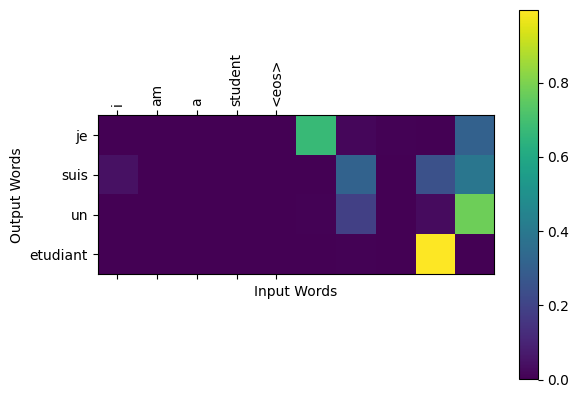

In [13]:
sentence = "i am a student"
output_words, attentions = evaluate(sentence)

print("Output:", " ".join(output_words))
show_attention(sentence, output_words, attentions)